# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Load Data

In [2]:
students_df = pd.read_csv("StudentsPerformance.csv")
print(students_df.head())
print(students_df.info())
print(students_df.describe())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtyp

# 3. Exploratory Data Analysis

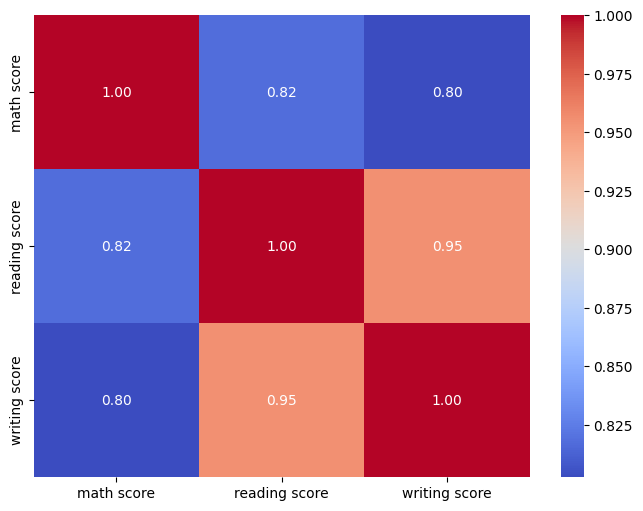

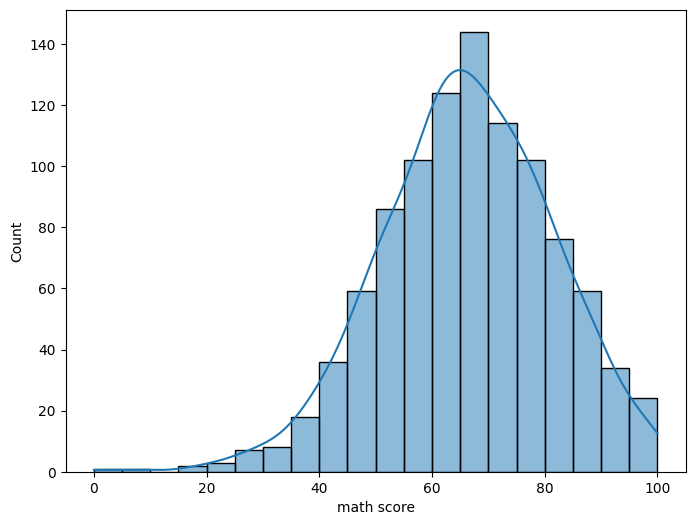

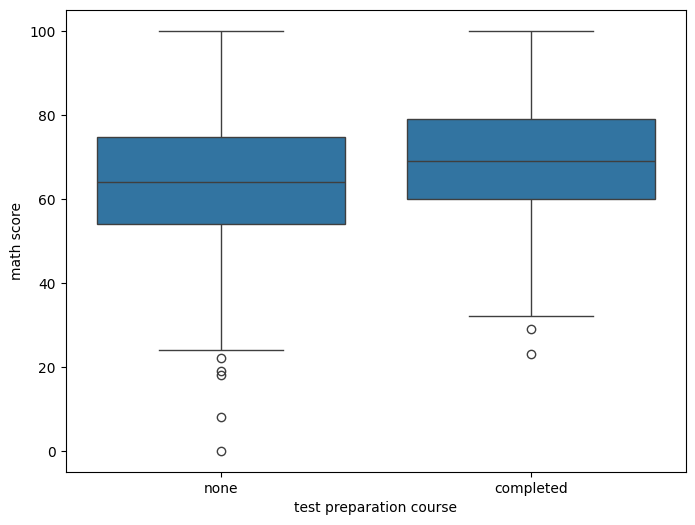

In [3]:
plt.figure(figsize=(8, 6))
sns.heatmap(students_df[['math score', 'reading score', 'writing score']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(students_df['math score'], bins=20, kde=True)
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='test preparation course', y='math score', data=students_df)
plt.show()

# 4. Data Cleaning

In [4]:
missing_values = students_df.isnull().sum()
print(missing_values)

duplicate_count = students_df.duplicated().sum()
print(duplicate_count)

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64
0


# 5. Feature Engineering

In [5]:
students_df = pd.get_dummies(students_df, columns=['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course'], dtype=int)
students_df['average_score'] = (students_df['math score'] + students_df['reading score'] + students_df['writing score']) / 3
print(students_df.head())

   math score  reading score  writing score  gender_female  gender_male  \
0          72             72             74              1            0   
1          69             90             88              1            0   
2          90             95             93              1            0   
3          47             57             44              0            1   
4          76             78             75              0            1   

   race/ethnicity_group A  race/ethnicity_group B  race/ethnicity_group C  \
0                       0                       1                       0   
1                       0                       0                       1   
2                       0                       1                       0   
3                       1                       0                       0   
4                       0                       0                       1   

   race/ethnicity_group D  race/ethnicity_group E  ...  \
0                       0   

# 6. Train-Test Split

In [6]:
X = students_df.drop(columns=['math score', 'reading score', 'writing score', 'average_score'])
y_math = students_df['math score']
y_reading = students_df['reading score']
y_writing = students_df['writing score']
y_average = students_df['average_score']

X_train, X_test, y_math_train, y_math_test, y_reading_train, y_reading_test, y_writing_train, y_writing_test, y_average_train, y_average_test = train_test_split(
    X, y_math, y_reading, y_writing, y_average, test_size=0.2, random_state=42
)

# 7. Train Models

In [7]:
lr_math = LinearRegression()
dt_math = DecisionTreeRegressor(max_depth=5, random_state=42)
rf_math = RandomForestRegressor(max_depth=5, random_state=42)

lr_math.fit(X_train, y_math_train)
dt_math.fit(X_train, y_math_train)
rf_math.fit(X_train, y_math_train)


lr_reading = LinearRegression()
dt_reading = DecisionTreeRegressor(max_depth=5, random_state=42)
rf_reading = RandomForestRegressor(max_depth=5, random_state=42)

lr_reading.fit(X_train, y_reading_train)
dt_reading.fit(X_train, y_reading_train)
rf_reading.fit(X_train, y_reading_train)


lr_writing = LinearRegression()
dt_writing = DecisionTreeRegressor(max_depth=5, random_state=42)
rf_writing = RandomForestRegressor(max_depth=5, random_state=42)

lr_writing.fit(X_train, y_writing_train)
dt_writing.fit(X_train, y_writing_train)
rf_writing.fit(X_train, y_writing_train)


lr_average = LinearRegression()
dt_average = DecisionTreeRegressor(max_depth=5, random_state=42)
rf_average = RandomForestRegressor(max_depth=5, random_state=42)

lr_average.fit(X_train, y_average_train)
dt_average.fit(X_train, y_average_train)
rf_average.fit(X_train, y_average_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 8. Evaluate and Compare

In [8]:
def evaluate_models_cv(models, X, y):
    results = []
    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=5, scoring='r2')
        mean_r2 = scores.mean()
        std_r2 = scores.std()
        results.append({"Model": name, "Mean R2": mean_r2, "Std R2": std_r2})
    return pd.DataFrame(results)

math_models = {"Linear Regression": lr_math, "Decision Tree": dt_math, "Random Forest": rf_math}
reading_models = {"Linear Regression": lr_reading, "Decision Tree": dt_reading, "Random Forest": rf_reading}
writing_models = {"Linear Regression": lr_writing, "Decision Tree": dt_writing, "Random Forest": rf_writing}
average_models = {"Linear Regression": lr_average, "Decision Tree": dt_average, "Random Forest": rf_average}

math_results = evaluate_models_cv(math_models, X, y_math)
reading_results = evaluate_models_cv(reading_models, X, y_reading)
writing_results = evaluate_models_cv(writing_models, X, y_writing)
average_results = evaluate_models_cv(average_models, X, y_average)

print("Math Score Results:")
print(math_results)
print("\nReading Score Results:")
print(reading_results)
print("\nWriting Score Results:")
print(writing_results)
print("\nAverage Score Results:")
print(average_results)

Math Score Results:
               Model   Mean R2    Std R2
0  Linear Regression  0.227900  0.042392
1      Decision Tree  0.108990  0.053986
2      Random Forest  0.166634  0.041353

Reading Score Results:
               Model   Mean R2    Std R2
0  Linear Regression  0.193708  0.061325
1      Decision Tree  0.068812  0.106275
2      Random Forest  0.131160  0.077944

Writing Score Results:
               Model   Mean R2    Std R2
0  Linear Regression  0.309262  0.048810
1      Decision Tree  0.193701  0.082974
2      Random Forest  0.248528  0.070640

Average Score Results:
               Model   Mean R2    Std R2
0  Linear Regression  0.212339  0.046525
1      Decision Tree  0.079187  0.090131
2      Random Forest  0.142964  0.064005


# 9. Feature Importance

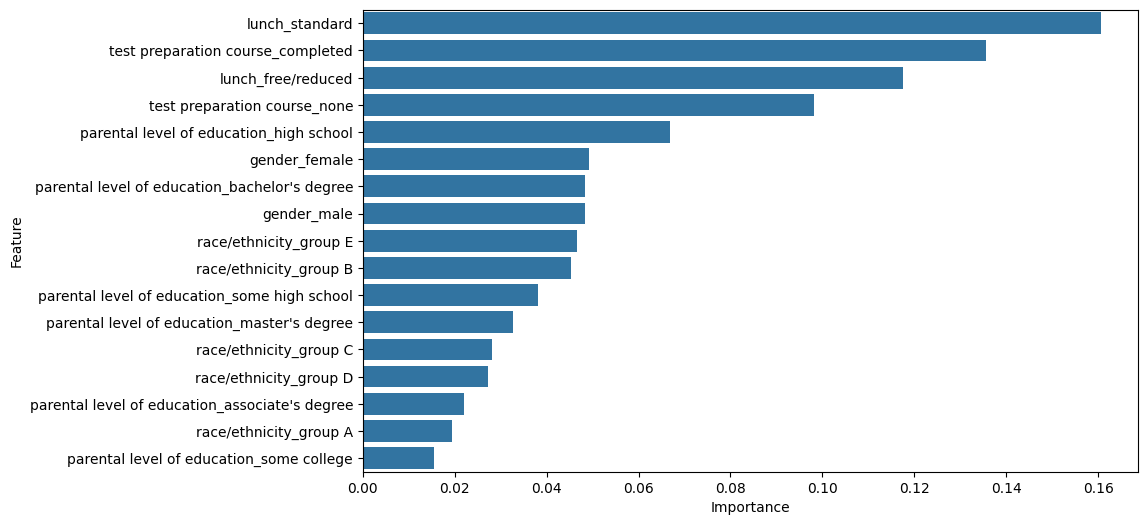

In [9]:
importance = rf_average.feature_importances_
features = X.columns
importance_df = pd.DataFrame({"Feature": features, "Importance": importance})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.show()

# 10. Best Model Selection

In [10]:
def get_best_model_cv(results_df):
    best_row = results_df.loc[results_df["Mean R2"].idxmax()]
    return best_row["Model"], best_row["Mean R2"], best_row["Std R2"]

best_math_model, best_math_mean, best_math_std = get_best_model_cv(math_results)
best_reading_model, best_reading_mean, best_reading_std = get_best_model_cv(reading_results)
best_writing_model, best_writing_mean, best_writing_std = get_best_model_cv(writing_results)
best_average_model, best_average_mean, best_average_std = get_best_model_cv(average_results)

print(f"Best model for Math Score: {best_math_model} with R² = {best_math_mean:.4f} ± {best_math_std:.4f}")
print(f"Best model for Reading Score: {best_reading_model} with R² = {best_reading_mean:.4f} ± {best_reading_std:.4f}")
print(f"Best model for Writing Score: {best_writing_model} with R² = {best_writing_mean:.4f} ± {best_writing_std:.4f}")
print(f"Best model for Average Score: {best_average_model} with R² = {best_average_mean:.4f} ± {best_average_std:.4f}")

Best model for Math Score: Linear Regression with R² = 0.2279 ± 0.0424
Best model for Reading Score: Linear Regression with R² = 0.1937 ± 0.0613
Best model for Writing Score: Linear Regression with R² = 0.3093 ± 0.0488
Best model for Average Score: Linear Regression with R² = 0.2123 ± 0.0465
